In [2]:
from nilearn import image
import numpy as np
import os.path as op
import pandas as pd
import glob
from scipy import io, stats
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
surprise_folder = "/mnt/d/multlearn-sns/SPM/results/spe_rpeBestOverall/betas/spe/"
rpe_folder = "/mnt/d/multlearn-sns/SPM/results/spe_rpeBestOverall/betas/rpeBestOverall/"

IDs = range(1, 65)
IDs = [i for i in IDs if i not in [8, 13, 16, 31, 32, 44]]

surprise_ROIs = [name for name in os.listdir(surprise_folder)
            if os.path.isdir(os.path.join(surprise_folder, name))]
rpe_ROIs = [name for name in os.listdir(rpe_folder)
            if os.path.isdir(os.path.join(rpe_folder, name)) and 'Cerebellum' not in name]
ROIs = surprise_ROIs + rpe_ROIs
betas_df = list()

audio_OrbitofrontalGyrus = list()
tactile_OrbitofrontalGyrus = list()
audio_AngularGyrus = list()
tactile_AngularGyrus = list()
for idx, i in enumerate(IDs):
    
    (surpriseAV_surpriseVT, surpriseAV_rpeAV, surpriseAV_rpeVT, rpeAV_rpeVT) = (
        list() for i in range(4)
    )
    id_betas = []
    for ROI in surprise_ROIs:
        for path, subdirs, files in os.walk(op.join(surprise_folder, ROI)):
            for name in files:
                if f'audio2betas_sub-{i:02d}' in name:
                    audiofn = os.path.join(path, name) if 'audio2' in name else np.nan
                    audio_beta = io.loadmat(audiofn)["audio2Betas"]
                if f'tactile2betas_sub-{i:02d}' in name:
                    tactilefn = os.path.join(path, name) if 'tactile2' in name else np.nan
                    tactile_beta = io.loadmat(tactilefn)["tactile2Betas"]
                    #print(os.path.join(path, name))
            id_betas.append(np.mean(np.sum([audio_beta, tactile_beta], axis=0)))
            if ROI == 'SpeAngularGyrus_R':
                    audio_AngularGyrus.append(np.sum(audio_beta))
                    tactile_AngularGyrus.append(np.sum(tactile_beta))

    for ROI in rpe_ROIs:
        for path, subdirs, files in os.walk(op.join(rpe_folder, ROI)):
            for name in files:
                if f'audio2betas_sub-{i:02d}' in name:
                    audiofn = os.path.join(path, name) if 'audio2' in name else np.nan
                    audio_beta = io.loadmat(audiofn)["audio2Betas"]
                if f'tactile2betas_sub-{i:02d}' in name:
                    tactilefn = os.path.join(path, name) if 'tactile2' in name else np.nan
                    tactile_beta = io.loadmat(tactilefn)["tactile2Betas"]
                    #print(os.path.join(path, name))
            id_betas.append(np.mean(np.sum([audio_beta, tactile_beta], axis=0)))
            if ROI == 'RpeMedialOrbitofrontalGyrus_R':
                    audio_OrbitofrontalGyrus.append(np.sum(audio_beta))
                    tactile_OrbitofrontalGyrus.append(np.sum(tactile_beta))
    betas_df.append(id_betas)
betas_df = pd.DataFrame(betas_df, columns=ROIs)

In [15]:
betas_df.columns

Index(['SpeAngularGyrus_L', 'SpeAngularGyrus_R', 'SpeMiddleFrontalGyrus_L',
       'SpePrecuneus_L', 'RpeAngularGyrus_L', 'RpeCaudate_R',
       'RpeCingulateGyrus_L', 'RpeMedialOrbitofrontalGyrus_R',
       'RpeMiddleOccipitalGyrus_L', 'RpePutamen_L', 'RpePutamen_R'],
      dtype='object')

(array([-10. ,  -7.5,  -5. ,  -2.5,   0. ,   2.5,   5. ,   7.5,  10. ,
         12.5]),
 [Text(0, -10.0, '−10.0'),
  Text(0, -7.5, '−7.5'),
  Text(0, -5.0, '−5.0'),
  Text(0, -2.5, '−2.5'),
  Text(0, 0.0, '0.0'),
  Text(0, 2.5, '2.5'),
  Text(0, 5.0, '5.0'),
  Text(0, 7.5, '7.5'),
  Text(0, 10.0, '10.0'),
  Text(0, 12.5, '12.5')])

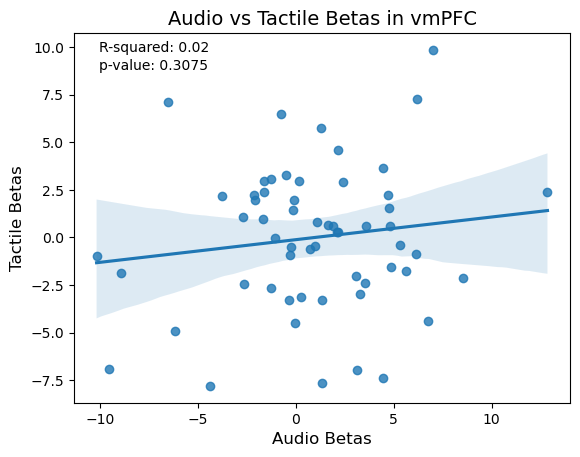

In [5]:
# Calculate Pearson correlation coefficient and p-value
corr, p_value = stats.pearsonr(audio_OrbitofrontalGyrus, tactile_OrbitofrontalGyrus)

# Create the scatter plot
sns.regplot(x=audio_OrbitofrontalGyrus, y=tactile_OrbitofrontalGyrus, ci=95)

# Add R-squared value and p-value to the plot
plt.text(0.05, 0.95, f"R-squared: {corr**2:.2f}", transform=plt.gca().transAxes)
plt.text(0.05, 0.90, f"p-value: {p_value:.4f}", transform=plt.gca().transAxes)

# Add axes labels
plt.xlabel("Audio Betas", fontsize=12)
plt.ylabel("Tactile Betas", fontsize=12)

# Add title
plt.title("Audio vs Tactile Betas in vmPFC", fontsize=14)

# Increase size of tick labels
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)


(array([-10. ,  -7.5,  -5. ,  -2.5,   0. ,   2.5,   5. ,   7.5,  10. ,
         12.5]),
 [Text(0, -10.0, '−10.0'),
  Text(0, -7.5, '−7.5'),
  Text(0, -5.0, '−5.0'),
  Text(0, -2.5, '−2.5'),
  Text(0, 0.0, '0.0'),
  Text(0, 2.5, '2.5'),
  Text(0, 5.0, '5.0'),
  Text(0, 7.5, '7.5'),
  Text(0, 10.0, '10.0'),
  Text(0, 12.5, '12.5')])

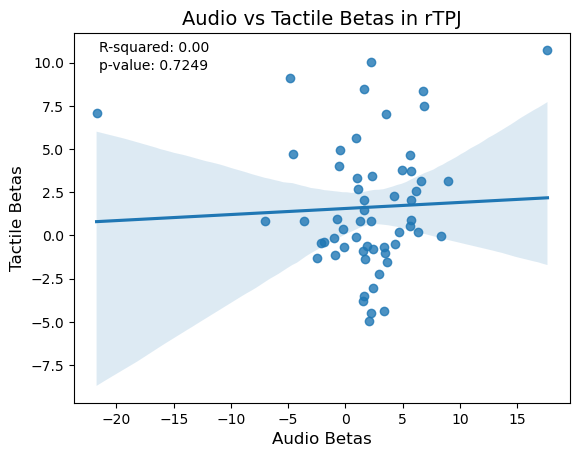

In [17]:
# Calculate Pearson correlation coefficient and p-value
corr, p_value = stats.pearsonr(audio_AngularGyrus, tactile_AngularGyrus)

# Create the scatter plot
sns.regplot(x=audio_AngularGyrus, y=tactile_AngularGyrus, ci=95)

# Add R-squared value and p-value to the plot
plt.text(0.05, 0.95, f"R-squared: {corr**2:.2f}", transform=plt.gca().transAxes)
plt.text(0.05, 0.90, f"p-value: {p_value:.4f}", transform=plt.gca().transAxes)

# Add axes labels
plt.xlabel("Audio Betas", fontsize=12)
plt.ylabel("Tactile Betas", fontsize=12)

# Add title
plt.title("Audio vs Tactile Betas in rTPJ", fontsize=14)

# Increase size of tick labels
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)


/home/ella/anaconda3/envs/nipype/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/ella/anaconda3/envs/nipype/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/ella/anaconda3/envs/nipype/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/ella/anaconda3/envs/nipype/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future versi

(array([-15., -10.,  -5.,   0.,   5.,  10.,  15.]),
 [Text(0, -15.0, '−15'),
  Text(0, -10.0, '−10'),
  Text(0, -5.0, '−5'),
  Text(0, 0.0, '0'),
  Text(0, 5.0, '5'),
  Text(0, 10.0, '10'),
  Text(0, 15.0, '15')])

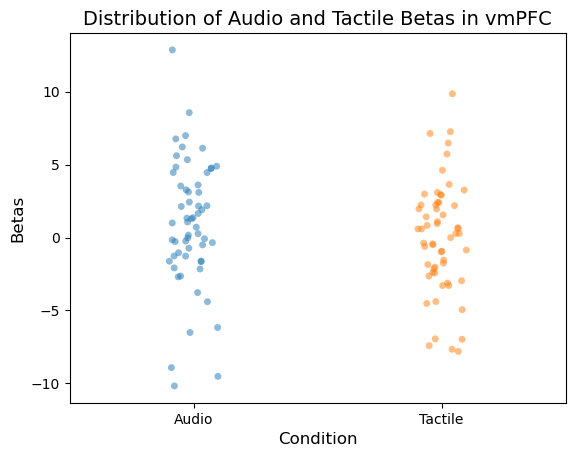

In [13]:
#sns.violinplot(data=[audio_OrbitofrontalGyrus, tactile_OrbitofrontalGyrus], inner=None, color=".8")
sns.stripplot(data=[audio_OrbitofrontalGyrus, tactile_OrbitofrontalGyrus], alpha=0.5)
# Add axes labels
plt.xlabel("Condition", fontsize=12)
plt.ylabel("Betas", fontsize=12)
# Set x tick labels
plt.xticks([0, 1], ["Audio", "Tactile"], fontsize=10)
# Add title
plt.title("Distribution of Audio and Tactile Betas in vmPFC", fontsize=14)
# Increase size of tick labels
plt.yticks(fontsize=10)


/home/ella/anaconda3/envs/nipype/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/ella/anaconda3/envs/nipype/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/ella/anaconda3/envs/nipype/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/ella/anaconda3/envs/nipype/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future versi

(array([-25., -20., -15., -10.,  -5.,   0.,   5.,  10.,  15.,  20.]),
 [Text(0, -25.0, '−25'),
  Text(0, -20.0, '−20'),
  Text(0, -15.0, '−15'),
  Text(0, -10.0, '−10'),
  Text(0, -5.0, '−5'),
  Text(0, 0.0, '0'),
  Text(0, 5.0, '5'),
  Text(0, 10.0, '10'),
  Text(0, 15.0, '15'),
  Text(0, 20.0, '20')])

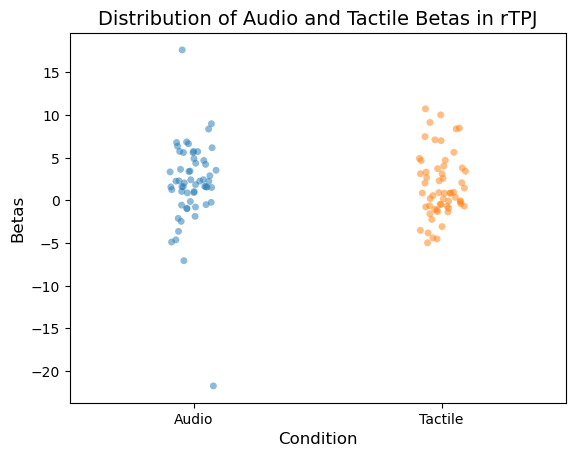

In [18]:
#sns.violinplot(data=[audio_OrbitofrontalGyrus, tactile_OrbitofrontalGyrus], inner=None, color=".8")
sns.stripplot(data=[audio_AngularGyrus, tactile_AngularGyrus], alpha=0.5)
# Add axes labels
plt.xlabel("Condition", fontsize=12)
plt.ylabel("Betas", fontsize=12)
# Set x tick labels
plt.xticks([0, 1], ["Audio", "Tactile"], fontsize=10)
# Add title
plt.title("Distribution of Audio and Tactile Betas in rTPJ", fontsize=14)
# Increase size of tick labels
plt.yticks(fontsize=10)


In [5]:
betas_df

,SpeAngularGyrus_L,SpeAngularGyrus_R,SpeMiddleFrontalGyrus_L,SpePrecuneus_L,RpeAngularGyrus_L,RpeCaudate_R,RpeCingulateGyrus_L,RpeMedialOrbitofrontalGyrus_R,RpeMiddleOccipitalGyrus_L,RpePutamen_L,RpePutamen_R
0,-0.336086,0.414652,0.975353,-1.363846,0.153198,-3.116694,-3.334035,-0.641686,-0.519887,-0.078167,1.142265
1,0.825057,0.201641,1.228354,0.512904,0.923718,-2.926382,-0.834035,1.283102,0.117152,1.201146,1.167106
2,1.617041,4.097996,-0.908346,4.689472,0.608067,3.362283,-0.509746,-0.243573,3.840307,0.448050,2.569783
3,1.354460,-0.966557,-0.744196,-0.689061,-2.419532,0.575781,-0.330154,-1.302371,-1.835605,-4.324074,-0.139178
4,1.365484,9.459914,2.145468,4.757327,0.275613,-6.525872,4.040357,5.087154,0.939443,0.062635,-0.162795
5,1.996104,1.453566,1.598394,2.460994,0.686077,0.702842,-1.931841,0.774249,-1.381653,-0.737245,-0.819898
6,0.311597,2.182990,0.688837,3.103657,-5.072787,-4.176538,2.448974,-0.953719,-1.428387,-5.462594,-4.369444
7,0.456779,-0.627977,0.659691,0.906097,2.875992,0.889032,-3.055666,0.383381,-0.627718,1.073690,0.548671
8,0.859271,-0.744307,1.580741,4.936931,7.976240,0.519154,1.029714,0.625139,8.215777,1.702814,4.239254
9,4.713087,2.923611,1.696454,2.154459,3.166602,1.769755,0.220479,0.810887,-4.522372,-4.518857,2.402354


<Axes: >

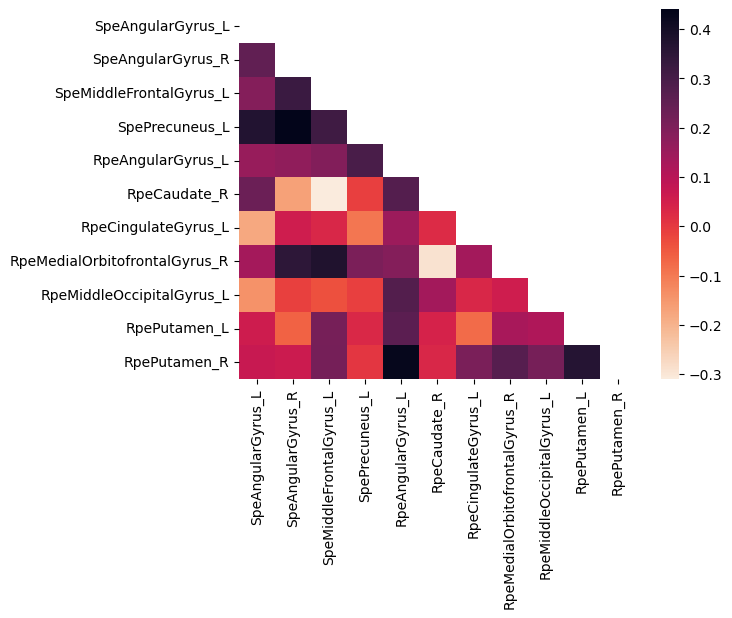

In [6]:
matrix = np.triu(betas_df.corr())
sns.heatmap(betas_df.corr(), mask=matrix, cmap='rocket_r')

In [10]:
import statsmodels.api as sm

# Assuming df is your DataFrame with the specified structure
# Extract the predictor variables and response variable
# df = df.dropna(axis=0)
for col in betas_df.columns:
    X = betas_df[[col]]
    y = betas_df.drop(col, axis=1)  # keep all other features
    print(betas_df.index)

# Standardize the predictor variables
    X = (X - X.mean()) / X.std()

# Fit the random effects model with increased iterations
    model = sm.MixedLM(y, X, groups=betas_df.index)
    result = model.fit()

# Print the model summary
    print(result.summary())


RangeIndex(start=0, stop=58, step=1)


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 3 dimension(s)